# Δy temperature-profile overlay (peak & fire1)
For each case, one plot holds many Δy offsets: T(z) on the YZ slice at x=8.1 m, sampled at y = fire_centre_y + Δy (Δy = 0.0…1.4 m), averaged over 300–360 s. Curves coloured by Δy; paper grid-conv references (Mesh1/Mesh5) overlaid in black. Based on `plot_e_convergence.py`; mirrors `plot_dy_profiles.py`.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import logging; logging.disable(logging.CRITICAL)
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import fdsreader
%matplotlib inline
plt.rcParams.update({'axes.labelsize':15,'axes.titlesize':15,
                     'xtick.labelsize':12,'ytick.labelsize':12,'legend.fontsize':9})
print('fdsreader', fdsreader.__version__)

fdsreader 1.11.7


In [2]:
ROOT = Path('/shared/home/wel1come1234/workspace/FDS/Engineroom')
RES  = ROOT/'Results'
CONV = ROOT/'Analysis'/'convergence'
REF_M1 = CONV/'ref_Mesh1.csv'   # paper grid-conv T(z), coarse
REF_M5 = CONV/'ref_Mesh5.csv'   # paper grid-conv T(z), fine

SLICE_X = 8.1
FIRE_CENTER_Y = 1.45
DY_VALUES = np.round(np.arange(15)*0.1, 1)   # 0.0 … 1.4 m
Z_PLOT = np.linspace(0.0, 3.0, 61)
WIN_AVG = (0.0, 360.0)

SERIES = {
    'peak':  ('peak{tp:02d}_M5',       '0.79 m^2 fire'),
    'fire1': ('peak{tp:02d}_fire1_M5', '1.0 m^2 fire'),
}
PEAK_TIMES = [5, 10, 15, 20]
CMAP = plt.cm.viridis
NORM = Normalize(vmin=DY_VALUES.min(), vmax=DY_VALUES.max())

In [3]:
def load_ref(p):
    if not p.exists(): return None, None
    z, T = [], []
    for ln in p.read_text().splitlines():
        ln = ln.strip()
        if not ln: continue
        a, b = ln.split(','); z.append(float(a)); T.append(float(b))
    return np.asarray(z), np.asarray(T)

def plot_refs(ax, refs, legend=True):
    (z1,T1),(z5,T5) = refs
    if z1 is not None: ax.plot(z1,T1,'k--s',lw=1.6,ms=4,mfc='none',label='Ref Mesh1 (paper)')
    if z5 is not None: ax.plot(z5,T5,'k-o', lw=1.6,ms=4,mfc='none',label='Ref Mesh5 (paper)')
    if legend and (z1 is not None or z5 is not None):
        ax.legend(loc='upper right', framealpha=0.95)

def load_sim(case):
    p = RES/case
    if not (p/f'{case}.smv').exists():
        print(f'  {case}: .smv missing'); return None
    try: return fdsreader.Simulation(str(p))
    except Exception as e: print(f'  {case}: {e}'); return None

def find_yz_temp(sim):
    cands = [(abs(s.extent.x_start - SLICE_X), s) for s in sim.slices
             if s.orientation == 1 and 'TEMP' in s.quantity.name.upper()]
    return min(cands, key=lambda t: t[0])[1] if cands else None

def T_avg_profiles(sim, win=WIN_AVG):
    sl = find_yz_temp(sim)
    if sl is None: return None
    t_arr = np.asarray(sl.times)
    t0, t1 = win[0], min(win[1], float(t_arr.max()))
    mask = (t_arr>=t0)&(t_arr<=t1)
    if not mask.any(): mask = np.array([int(np.argmax(t_arr))])
    T_all = sl.to_global(masked=True, fill=np.nan)   # (t, y, z)
    ext = sl.extent
    y_arr = np.linspace(ext.y_start, ext.y_end, T_all.shape[1])
    z_arr = np.linspace(ext.z_start, ext.z_end, T_all.shape[2])
    out = {}
    for dy in DY_VALUES:
        iy = int(np.argmin(np.abs(y_arr - (FIRE_CENTER_Y+dy))))
        out[dy] = np.interp(Z_PLOT, z_arr, np.nanmean(T_all[mask, iy, :], axis=0))
    return out

def style_ax(ax):
    ax.set_xlabel('Height z (m)'); ax.set_ylabel('Temperature (\u00b0C)')
    ax.set_xlim(0,3); ax.set_ylim(bottom=20); ax.grid(alpha=0.3)
    ax.axvline(1.0, color='lightgray', lw=1.0, ls=':', zorder=0)
    ax.axvline(2.0, color='lightgray', lw=1.0, ls=':', zorder=0)

=== peak (0.79 m^2 fire) ===


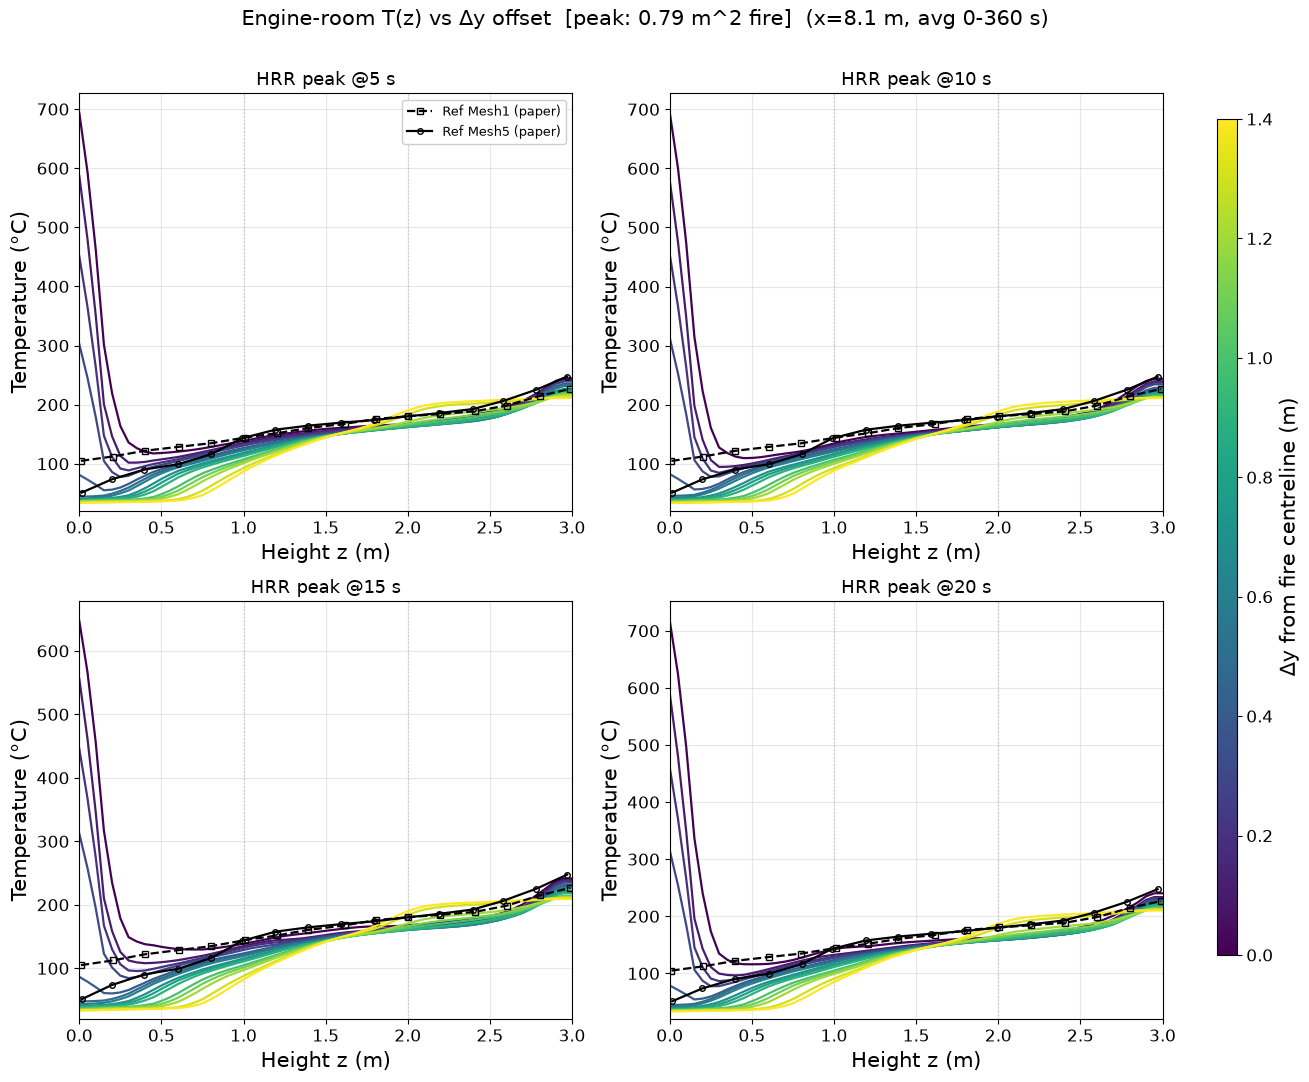

=== fire1 (1.0 m^2 fire) ===


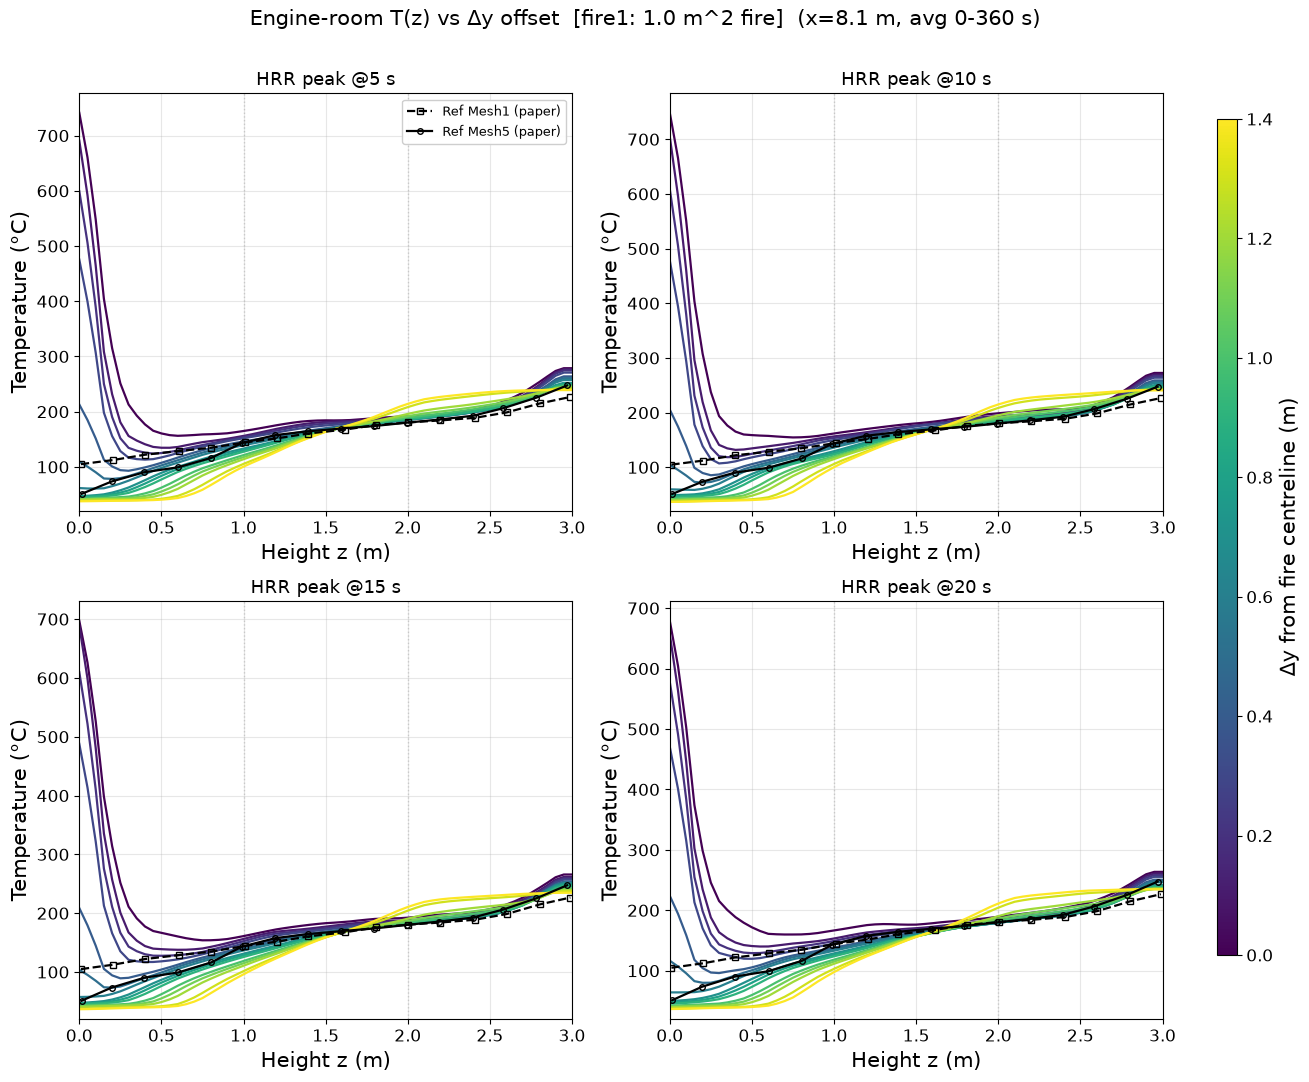

In [4]:
def run_series(series, save=True):
    tmpl, tag = SERIES[series]
    OUT = CONV/series; OUT.mkdir(parents=True, exist_ok=True)
    print(f'=== {series} ({tag}) ===')
    refs = (load_ref(REF_M1), load_ref(REF_M5))
    fig, axs = plt.subplots(2, 2, figsize=(13, 11)); axs = axs.ravel()
    for k, tp in enumerate(PEAK_TIMES):
        case = tmpl.format(tp=tp)
        sim = load_sim(case)
        if sim is None: continue
        prof = T_avg_profiles(sim)
        if prof is None: print(f'  {case}: no slice'); continue
        f1, a1 = plt.subplots(figsize=(7.5, 6))
        for dy in DY_VALUES:
            a1.plot(Z_PLOT, prof[dy], '-', lw=1.8, color=CMAP(NORM(dy)))
        plot_refs(a1, refs); style_ax(a1)
        a1.set_title(f'{case} — T(z) vs \u0394y\nx={SLICE_X} m, avg {WIN_AVG[0]:.0f}-{WIN_AVG[1]:.0f} s [{tag}]', fontsize=13)
        cb = f1.colorbar(ScalarMappable(norm=NORM, cmap=CMAP), ax=a1, ticks=DY_VALUES[::2])
        cb.set_label('\u0394y from fire centreline (m)')
        f1.tight_layout()
        if save: f1.savefig(OUT/f'{case}_dy_avg.png', dpi=150)
        plt.close(f1)
        for dy in DY_VALUES:
            axs[k].plot(Z_PLOT, prof[dy], '-', lw=1.6, color=CMAP(NORM(dy)))
        plot_refs(axs[k], refs, legend=(k==0)); style_ax(axs[k])
        axs[k].set_title(f'HRR peak @{tp} s', fontsize=13)
    fig.suptitle(f'Engine-room T(z) vs \u0394y offset  [{series}: {tag}]  (x={SLICE_X} m, avg {WIN_AVG[0]:.0f}-{WIN_AVG[1]:.0f} s)', fontsize=15)
    fig.tight_layout(rect=(0,0,0.92,0.97))
    cax = fig.add_axes([0.94, 0.12, 0.015, 0.76])
    cb = fig.colorbar(ScalarMappable(norm=NORM, cmap=CMAP), cax=cax, ticks=DY_VALUES[::2])
    cb.set_label('\u0394y from fire centreline (m)')
    if save: fig.savefig(OUT/f'{series}_dy_panel.png', dpi=150)
    plt.show()

run_series('peak')
run_series('fire1')